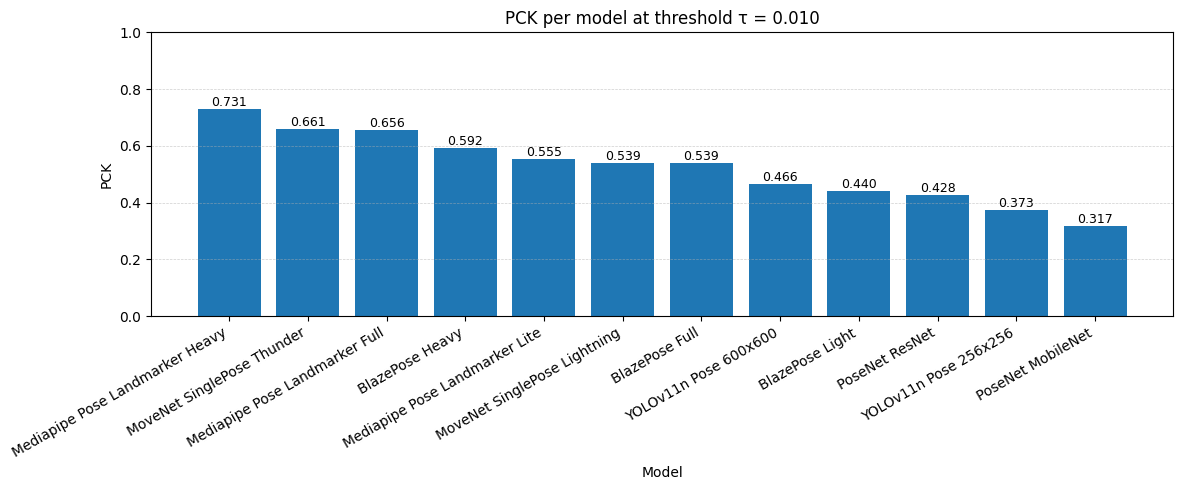

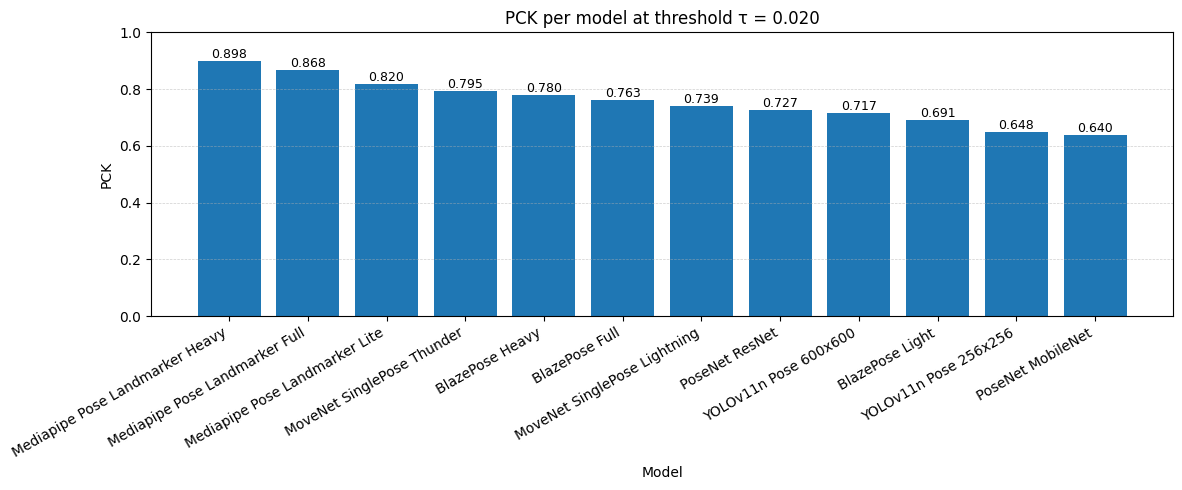

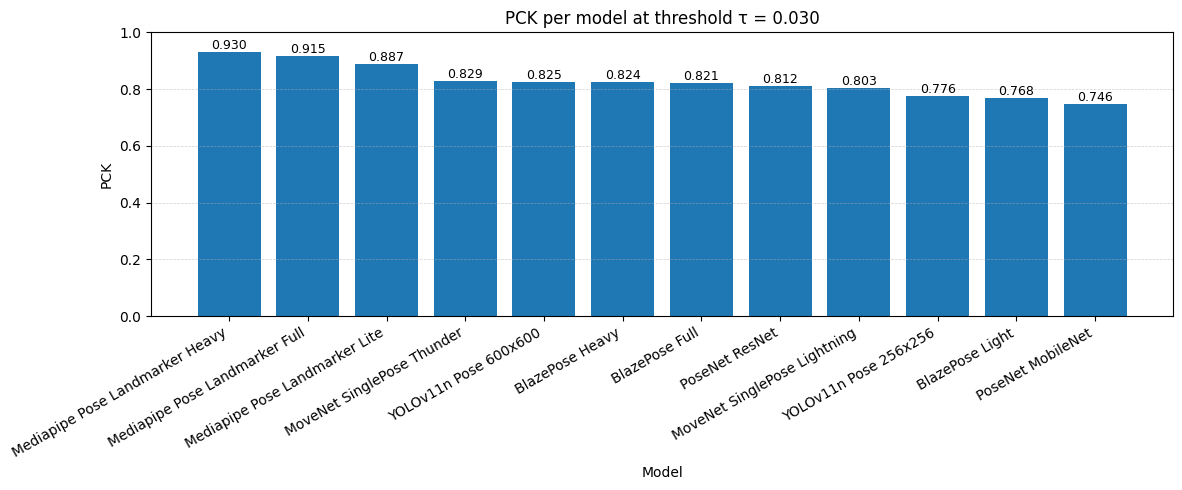

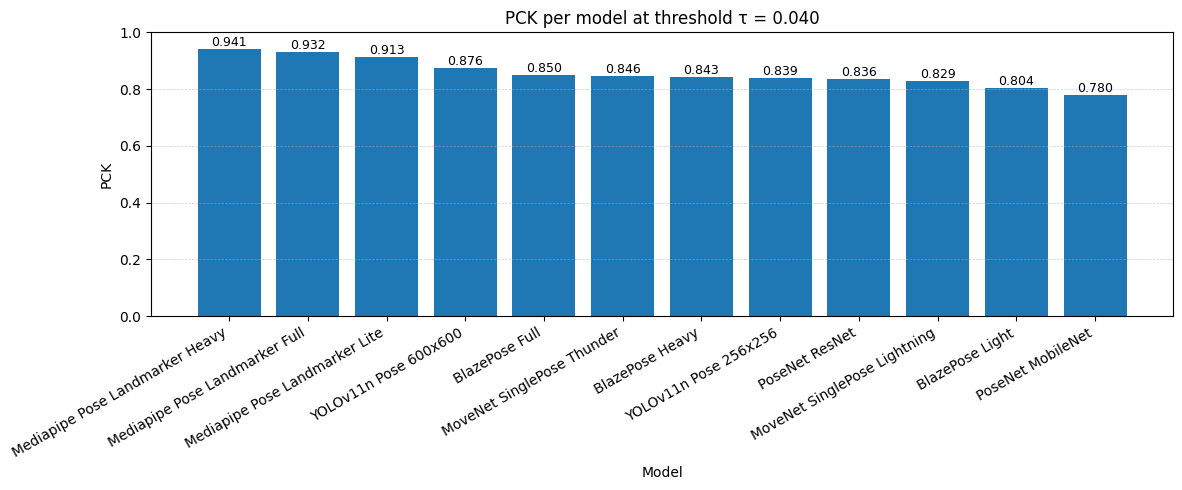

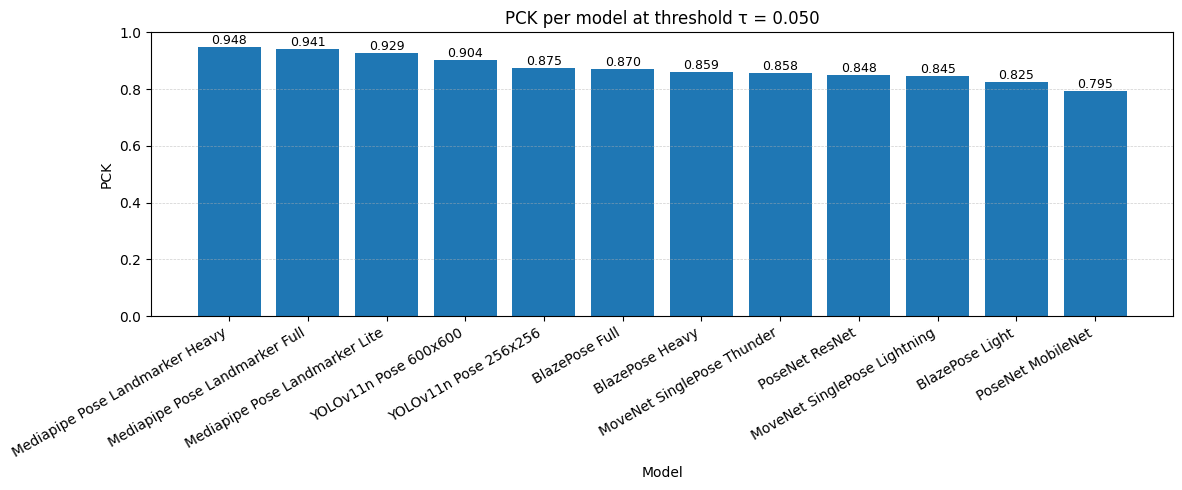

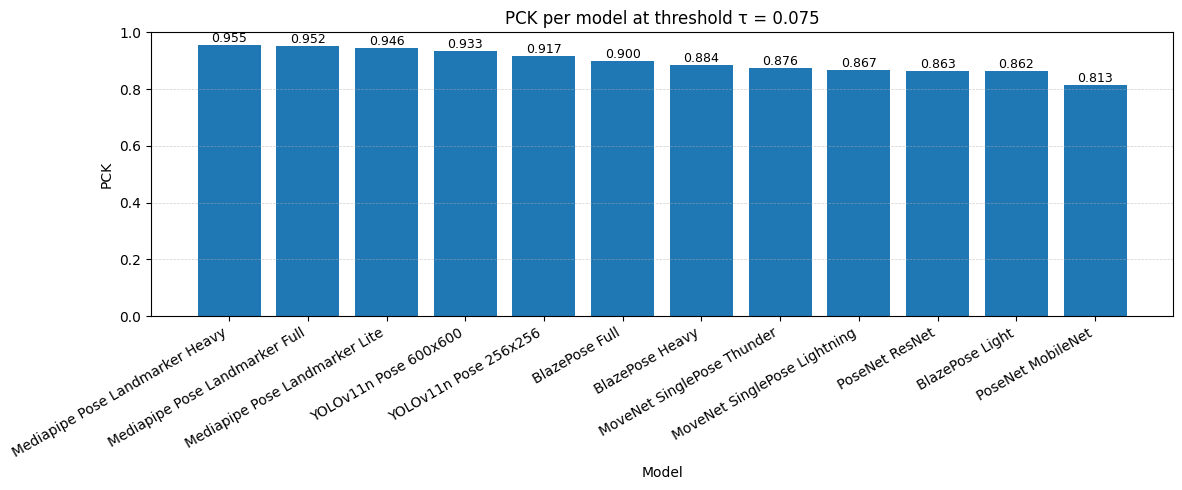

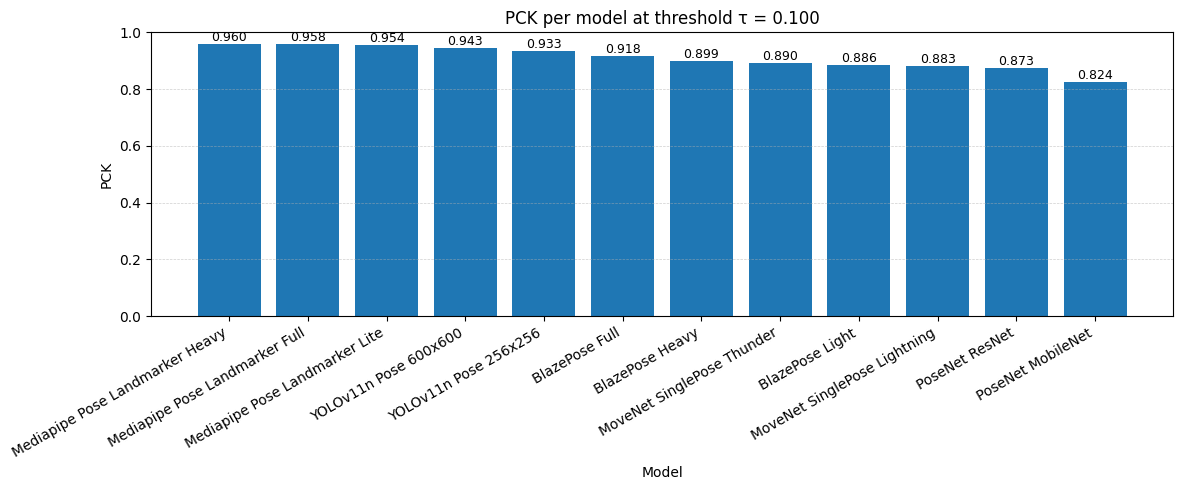

GT model: RTMO_X

τ=0.010
  Mediapipe Pose Landmarker Heavy  PCK=0.731
  MoveNet SinglePose Thunder    PCK=0.661
  Mediapipe Pose Landmarker Full  PCK=0.656
  BlazePose Heavy               PCK=0.592
  Mediapipe Pose Landmarker Lite  PCK=0.555
  MoveNet SinglePose Lightning  PCK=0.539
  BlazePose Full                PCK=0.539
  YOLOv11n Pose 600x600         PCK=0.466
  BlazePose Light               PCK=0.440
  PoseNet ResNet                PCK=0.428
  YOLOv11n Pose 256x256         PCK=0.373
  PoseNet MobileNet             PCK=0.317

τ=0.020
  Mediapipe Pose Landmarker Heavy  PCK=0.898
  Mediapipe Pose Landmarker Full  PCK=0.868
  Mediapipe Pose Landmarker Lite  PCK=0.820
  MoveNet SinglePose Thunder    PCK=0.795
  BlazePose Heavy               PCK=0.780
  BlazePose Full                PCK=0.763
  MoveNet SinglePose Lightning  PCK=0.739
  PoseNet ResNet                PCK=0.727
  YOLOv11n Pose 600x600         PCK=0.717
  BlazePose Light               PCK=0.691
  YOLOv11n Pose 256x256    

In [5]:
from __future__ import annotations

import json
import math
import os
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Config
# -----------------------------
GT_MODEL_NAME = "RTMO_X"
SKIP_MODELS = {"YOLO256_trained_on_own_dataset"}  # e.g. {"model_to_skip"}

# PCK thresholds (τ) in normalized units (your x/y are in [0,1])
THRESHOLDS = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.10], dtype=np.float32)

ALLOW_MISSING_IMAGES = True
ALLOW_MISSING_KEYPOINTS = True


# -----------------------------
# Data structures
# -----------------------------
Point = Tuple[float, float]
KeypointMap = Dict[str, Point]          # keypoint_id -> (x,y)
ImageMap = Dict[str, KeypointMap]       # file -> keypoint map


@dataclass
class ModelData:
    name: str
    images: ImageMap


# -----------------------------
# Loading
# -----------------------------
def load_model_json(path: str) -> ModelData:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    name = data.get("model")
    if not name:
        raise ValueError(f"Missing 'model' field in {path}")

    images: ImageMap = {}
    for item in data.get("keypointsOnImages", []):
        file_name = item.get("file")
        if not file_name:
            continue

        kp_map: KeypointMap = {}
        for kp in item.get("keypoints", []):
            kp_id = kp.get("id")
            pos = kp.get("pixelPosition") or {}
            if kp_id is None or "x" not in pos or "y" not in pos:
                continue
            kp_map[str(kp_id)] = (float(pos["x"]), float(pos["y"]))

        images[str(file_name)] = kp_map

    return ModelData(name=name, images=images)


def list_json_files(input_path: str) -> List[str]:
    if os.path.isdir(input_path):
        files = [
            os.path.join(input_path, f)
            for f in os.listdir(input_path)
            if f.lower().endswith(".json")
        ]
        files.sort()
        return files

    if os.path.isfile(input_path) and input_path.lower().endswith(".json"):
        return [input_path]

    raise ValueError("input_path must be a directory of .json files or a single .json file")


# -----------------------------
# Metrics
# -----------------------------
def euclidean(a: Point, b: Point) -> float:
    return math.hypot(a[0] - b[0], a[1] - b[1])


def gather_distances(pred: ModelData, gt: ModelData) -> np.ndarray:
    """
    Collect all per-keypoint Euclidean distances between pred and GT
    over all overlapping images and overlapping keypoint ids.
    """
    pred_files = set(pred.images.keys())
    gt_files = set(gt.images.keys())
    common_files = pred_files & gt_files

    if not common_files:
        raise ValueError(f"No overlapping images between {pred.name} and {gt.name}")

    if not ALLOW_MISSING_IMAGES:
        missing = gt_files - pred_files
        if missing:
            raise ValueError(f"{pred.name} missing {len(missing)} GT images")

    dists: List[float] = []
    for file_name in sorted(common_files):
        pred_kps = pred.images[file_name]
        gt_kps = gt.images[file_name]

        pred_ids = set(pred_kps.keys())
        gt_ids = set(gt_kps.keys())
        common_ids = pred_ids & gt_ids

        if not common_ids:
            continue

        if not ALLOW_MISSING_KEYPOINTS:
            missing_kps = gt_ids - pred_ids
            if missing_kps:
                raise ValueError(f"{pred.name} missing keypoints on {file_name}")

        for kp_id in common_ids:
            dists.append(euclidean(pred_kps[kp_id], gt_kps[kp_id]))

    if not dists:
        raise ValueError(f"No overlapping keypoints between {pred.name} and {gt.name}")

    return np.asarray(dists, dtype=np.float32)


def pck_from_distances(distances: np.ndarray, tau: float) -> float:
    return float((distances <= tau).mean())


# -----------------------------
# Plotting: ONE bar chart PER threshold
# -----------------------------
def plot_bars_per_threshold(
    model_to_dists: Dict[str, np.ndarray],
    thresholds: np.ndarray,
    out_dir: Optional[str] = None,
) -> None:
    names = list(model_to_dists.keys())

    for tau in thresholds:
        # Compute PCK per model at this tau
        vals = [(name, pck_from_distances(model_to_dists[name], float(tau))) for name in names]
        # Sort descending so best model is left
        vals.sort(key=lambda x: x[1], reverse=True)

        labels = [v[0] for v in vals]
        scores = [v[1] for v in vals]

        plt.figure(figsize=(12, 5))
        bars = plt.bar(labels, scores)

        # add value labels on top of each bar
        for b in bars:
            h = b.get_height()
            plt.text(
                b.get_x() + b.get_width() / 2,
                h,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
        plt.title(f"PCK per model at threshold τ = {float(tau):.3f}")
        plt.xlabel("Model")
        plt.ylabel("PCK")
        plt.ylim(0.0, 1.0)
        plt.xticks(rotation=30, ha="right")
        plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
        plt.tight_layout()

        if out_dir:
            os.makedirs(out_dir, exist_ok=True)
            fname = f"pck_bar_tau_{float(tau):.3f}.png".replace(".", "_")
            plt.savefig(os.path.join(out_dir, fname), dpi=200)

    plt.show()


# -----------------------------
# Main
# -----------------------------
def main(input_path: str, out_dir: Optional[str] = None) -> None:
    paths = list_json_files(input_path)
    models = [load_model_json(p) for p in paths]

    gt_candidates = [m for m in models if m.name == GT_MODEL_NAME]
    if not gt_candidates:
        raise ValueError(
            f"GT model '{GT_MODEL_NAME}' not found. "
            f"Found: {[m.name for m in models]}"
        )
    gt = gt_candidates[0]

    # Collect distances for each model vs GT
    model_to_dists: Dict[str, np.ndarray] = {}
    for m in models:
        if m.name == GT_MODEL_NAME or m.name in SKIP_MODELS:
            continue
        model_to_dists[m.name] = gather_distances(m, gt)

    # Create one bar chart per threshold
    plot_bars_per_threshold(model_to_dists, THRESHOLDS, out_dir=out_dir)

    # Print a compact table for convenience
    print(f"GT model: {GT_MODEL_NAME}")
    for tau in THRESHOLDS:
        row = []
        for name, d in model_to_dists.items():
            row.append((name, pck_from_distances(d, float(tau))))
        row.sort(key=lambda x: x[1], reverse=True)
        print(f"\nτ={float(tau):.3f}")
        for name, v in row:
            print(f"  {name:28s}  PCK={v:.3f}")


input_path = r"D:\Magistrska\blindoff-magistrska\fitcode-frontend-next\public\exercise-cut-videos-to-images\test-blindoff-dataset\results"
main(input_path, out_dir=None)